In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 24.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found exi

In [2]:
# Cell 1: Imports and Random Seed Setup
import os
import numpy as np
import pandas as pd
from PIL import Image
import shutil
import time
import yaml
from pathlib import Path
from tqdm.notebook import tqdm  # For progress bars in Jupyter/Kaggle environments

import torch
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from ultralytics import YOLO
import json

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

print("Libraries imported and seeds set!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported and seeds set!


In [3]:
# Cell 2: Define Paths, Variables, and Create YOLO Dataset Directories

# Data directory from competition input
data_path = "/kaggle/input/byu-locating-bacterial-flagellar-motors-2025/"
train_dir = os.path.join(data_path, "train")

# Define YOLO dataset structure inside /kaggle/working
yolo_dataset_dir = "/kaggle/working/yolo_dataset"
yolo_images_train = os.path.join(yolo_dataset_dir, "images", "train")
yolo_images_val = os.path.join(yolo_dataset_dir, "images", "val")
yolo_labels_train = os.path.join(yolo_dataset_dir, "labels", "train")
yolo_labels_val = os.path.join(yolo_dataset_dir, "labels", "val")

# Define YOLO weights directory (ADDED TO FIX THE ERROR)
yolo_weights_dir = "/kaggle/working/yolo_weights"

# Create required directories
for dir_path in [yolo_images_train, yolo_images_val, yolo_labels_train, yolo_labels_val, yolo_weights_dir]:
    os.makedirs(dir_path, exist_ok=True)

# Define additional constants for dataset processing
TRUST = 4         # Number of slices above and below the center slice
BOX_SIZE = 24     # Bounding box size (in pixels)
TRAIN_SPLIT = 0.8 # 80% for training, 20% for validation

# Define YOLO pretrained weights file (ensure this file is available)
yolo_pretrained_weights = "/kaggle/working/yolo_weights/yolov8l.pt"

print("Paths defined, directories created, and yolo_pretrained_weights set!")

Paths defined, directories created, and yolo_pretrained_weights set!


In [4]:
# Cell 3: Image Processing Function

def normalize_slice(slice_data):
    """
    Normalize slice data using 2nd and 98th percentiles.
    """
    p2 = np.percentile(slice_data, 2)
    p98 = np.percentile(slice_data, 98)
    clipped_data = np.clip(slice_data, p2, p98)
    normalized = 255 * (clipped_data - p2) / (p98 - p2)
    return np.uint8(normalized)

print("Image normalization function defined.")


Image normalization function defined.


In [5]:
# Cell 4: Preprocess and Prepare YOLO Dataset

def prepare_yolo_dataset(trust=TRUST, train_split=TRAIN_SPLIT):
    """
    Extract slices containing motors from tomograms and save to YOLO structure with annotations.
    """
    # Load the labels CSV file
    labels_df = pd.read_csv(os.path.join(data_path, "train_labels.csv"))
    
    # Count total number of motors
    total_motors = labels_df['Number of motors'].sum()
    print(f"Total number of motors in the dataset: {total_motors}")
    
    # Filter tomograms that have motors
    tomo_df = labels_df[labels_df['Number of motors'] > 0].copy()
    unique_tomos = tomo_df['tomo_id'].unique()
    print(f"Found {len(unique_tomos)} unique tomograms with motors")
    
    # Shuffle and split tomograms into training and validation sets
    np.random.shuffle(unique_tomos)
    split_idx = int(len(unique_tomos) * train_split)
    train_tomos = unique_tomos[:split_idx]
    val_tomos = unique_tomos[split_idx:]
    print(f"Split: {len(train_tomos)} tomograms for training, {len(val_tomos)} for validation")
    
    def process_tomogram_set(tomogram_ids, images_dir, labels_dir, set_name):
        motor_counts = []
        for tomo_id in tomogram_ids:
            # Get all motors for this tomogram
            tomo_motors = labels_df[labels_df['tomo_id'] == tomo_id]
            for _, motor in tomo_motors.iterrows():
                if pd.isna(motor['Motor axis 0']):
                    continue
                motor_counts.append(
                    (tomo_id, 
                     int(motor['Motor axis 0']), 
                     int(motor['Motor axis 1']), 
                     int(motor['Motor axis 2']),
                     int(motor['Array shape (axis 0)']))
                )
        
        print(f"Will process approximately {len(motor_counts) * (2 * trust + 1)} slices for {set_name}")
        processed_slices = 0
        
        for tomo_id, z_center, y_center, x_center, z_max in tqdm(motor_counts, desc=f"Processing {set_name} motors"):
            # Determine the slice range
            z_min = max(0, z_center - trust)
            z_max = min(z_max - 1, z_center + trust)
            
            for z in range(z_min, z_max + 1):
                # Construct the slice filename
                slice_filename = f"slice_{z:04d}.jpg"
                src_path = os.path.join(train_dir, tomo_id, slice_filename)
                if not os.path.exists(src_path):
                    print(f"Warning: {src_path} does not exist, skipping.")
                    continue
                
                # Load and normalize the slice
                img = Image.open(src_path)
                img_array = np.array(img)
                normalized_img = normalize_slice(img_array)
                
                # Build unique destination filename
                dest_filename = f"{tomo_id}_z{z:04d}_y{y_center:04d}_x{x_center:04d}.jpg"
                dest_path = os.path.join(images_dir, dest_filename)  # FIXED
                Image.fromarray(normalized_img).save(dest_path)
                
                # Get image dimensions
                img_width, img_height = img.size
                
                # Create YOLO format label (normalized coordinates)
                x_center_norm = x_center / img_width
                y_center_norm = y_center / img_height
                box_width_norm = BOX_SIZE / img_width
                box_height_norm = BOX_SIZE / img_height
                
                # Write the label file
                label_path = os.path.join(labels_dir, dest_filename.replace('.jpg', '.txt'))  # FIXED
                with open(label_path, 'w') as f:
                    f.write(f"0 {x_center_norm} {y_center_norm} {box_width_norm} {box_height_norm}\n")
                
                processed_slices += 1
        
        return processed_slices, len(motor_counts)
    
    # Process training tomograms
    train_slices, train_motors = process_tomogram_set(train_tomos, yolo_images_train, yolo_labels_train, "training")
    # Process validation tomograms
    val_slices, val_motors = process_tomogram_set(val_tomos, yolo_images_val, yolo_labels_val, "validation")
    
    # Create a YAML configuration for YOLO training
    yaml_content = {
        'path': yolo_dataset_dir,
        'train': 'images/train',
        'val': 'images/val',
        'names': {0: 'motor'}
    }
    
    yaml_out_path = os.path.join(yolo_dataset_dir, 'dataset.yaml')
    with open(yaml_out_path, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False)
    
    print("\nProcessing Summary:")
    print(f"- Train set: {len(train_tomos)} tomograms, {train_motors} motors, {train_slices} slices")
    print(f"- Validation set: {len(val_tomos)} tomograms, {val_motors} motors, {val_slices} slices")
    print(f"YAML configuration saved at: {yaml_out_path}")
    
    return {
        "dataset_dir": yolo_dataset_dir,
        "yaml_path": yaml_out_path,
        "train_tomograms": len(train_tomos),
        "val_tomograms": len(val_tomos),
        "train_motors": train_motors,
        "val_motors": val_motors,
        "train_slices": train_slices,
        "val_slices": val_slices
    }

# Run dataset preprocessing
summary = prepare_yolo_dataset(TRUST)
print("\nPreprocessing Complete:")
print(f"- Training data: {summary['train_tomograms']} tomograms, {summary['train_motors']} motors, {summary['train_slices']} slices")
print(f"- Validation data: {summary['val_tomograms']} tomograms, {summary['val_motors']} motors, {summary['val_slices']} slices")
print(f"- Dataset directory: {summary['dataset_dir']}")
print(f"- YAML configuration: {summary['yaml_path']}")
print("\nReady for YOLO training!")


Total number of motors in the dataset: 831
Found 362 unique tomograms with motors
Split: 289 tomograms for training, 73 for validation
Will process approximately 3267 slices for training


Processing training motors:   0%|          | 0/363 [00:00<?, ?it/s]

Will process approximately 792 slices for validation


Processing validation motors:   0%|          | 0/88 [00:00<?, ?it/s]


Processing Summary:
- Train set: 289 tomograms, 363 motors, 3262 slices
- Validation set: 73 tomograms, 88 motors, 792 slices
YAML configuration saved at: /kaggle/working/yolo_dataset/dataset.yaml

Preprocessing Complete:
- Training data: 289 tomograms, 363 motors, 3262 slices
- Validation data: 73 tomograms, 88 motors, 792 slices
- Dataset directory: /kaggle/working/yolo_dataset
- YAML configuration: /kaggle/working/yolo_dataset/dataset.yaml

Ready for YOLO training!


In [6]:
# Cell 5: YOLO Training and Prediction Helper Functions

def fix_yaml_paths(yaml_path):
    """
    Fix the paths in the YAML file to match the actual Kaggle directories.
    
    Args:
        yaml_path (str): Path to the original YAML file.
        
    Returns:
        str: Path to the fixed YAML file.
    """
    print(f"Fixing YAML paths in {yaml_path}")
    with open(yaml_path, 'r') as f:
        yaml_data = yaml.safe_load(f)
    
    if 'path' in yaml_data:
        yaml_data['path'] = yolo_dataset_dir
    fixed_yaml_path = "/kaggle/working/fixed_dataset.yaml"
    with open(fixed_yaml_path, 'w') as f:
        yaml.dump(yaml_data, f)
    print(f"Created fixed YAML at {fixed_yaml_path} with path: {yaml_data.get('path')}")
    return fixed_yaml_path

def plot_dfl_loss_curve(run_dir):
    """
    Plot the DFL loss curves for training and validation, marking the best model.
    
    Args:
        run_dir (str): Directory where the training results are stored.
    """
    results_csv = os.path.join(run_dir, 'results.csv')
    if not os.path.exists(results_csv):
        print(f"Results file not found at {results_csv}")
        return
    results_df = pd.read_csv(results_csv)
    train_dfl_col = [col for col in results_df.columns if 'train/dfl_loss' in col]
    val_dfl_col = [col for col in results_df.columns if 'val/dfl_loss' in col]
    
    if not train_dfl_col or not val_dfl_col:
        print("DFL loss columns not found in results CSV")
        print(f"Available columns: {results_df.columns.tolist()}")
        return
    
    train_dfl_col = train_dfl_col[0]
    val_dfl_col = val_dfl_col[0]
    
    best_epoch = results_df[val_dfl_col].idxmin()
    best_val_loss = results_df.loc[best_epoch, val_dfl_col]
    
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['epoch'], results_df[train_dfl_col], label='Train DFL Loss')
    plt.plot(results_df['epoch'], results_df[val_dfl_col], label='Validation DFL Loss')
    plt.axvline(x=results_df.loc[best_epoch, 'epoch'], color='r', linestyle='--', 
                label=f'Best Model (Epoch {int(results_df.loc[best_epoch, "epoch"])}, Val Loss: {best_val_loss:.4f})')
    plt.xlabel('Epoch')
    plt.ylabel('DFL Loss')
    plt.title('Training and Validation DFL Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plot_path = os.path.join(run_dir, 'dfl_loss_curve.png')
    plt.savefig(plot_path)
    plt.savefig(os.path.join('/kaggle/working', 'dfl_loss_curve.png'))
    print(f"Loss curve saved to {plot_path}")
    plt.close()
    
    return best_epoch, best_val_loss

def train_yolo_model(yaml_path, pretrained_weights_path, epochs=30, batch_size=16, img_size=640):
    """
    Train a YOLO model on the prepared dataset.
    
    Args:
        yaml_path (str): Path to the dataset YAML file.
        pretrained_weights_path (str): Path to pre-downloaded weights file.
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training.
        img_size (int): Image size for training.
    """
    print(f"Loading pre-trained weights from: {pretrained_weights_path}")
    model = YOLO(pretrained_weights_path)
    
    results = model.train(
        data=yaml_path,
        epochs=epochs,
        batch=batch_size,
        imgsz=img_size,
        project=yolo_weights_dir,
        name='motor_detector',
        exist_ok=True,
        patience=5,
        save_period=5,
        val=True,
        verbose=True
    )
    
    run_dir = os.path.join(yolo_weights_dir, 'motor_detector')
    best_epoch_info = plot_dfl_loss_curve(run_dir)
    if best_epoch_info:
        best_epoch, best_val_loss = best_epoch_info
        print(f"\nBest model found at epoch {best_epoch} with validation DFL loss: {best_val_loss:.4f}")
    
    return model, results

def predict_on_samples(model, num_samples=4):
    """
    Run predictions on random validation samples and display results.
    
    Args:
        model: Trained YOLO model.
        num_samples (int): Number of random samples to test.
    """
    val_dir = os.path.join(yolo_dataset_dir, 'images', 'val')
    if not os.path.exists(val_dir):
        print(f"Validation directory not found at {val_dir}")
        val_dir = os.path.join(yolo_dataset_dir, 'images', 'train')
        print(f"Using train directory for predictions instead: {val_dir}")
    if not os.path.exists(val_dir):
        print("No images directory found for predictions")
        return
    
    val_images = os.listdir(val_dir)
    if len(val_images) == 0:
        print("No images found for prediction")
        return
    
    num_samples = min(num_samples, len(val_images))
    samples = random.sample(val_images, num_samples)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for i, img_file in enumerate(samples):
        if i >= len(axes):
            break
        img_path = os.path.join(val_dir, img_file)
        results = model.predict(img_path, conf=0.25)[0]
        img = Image.open(img_path)
        axes[i].imshow(np.array(img), cmap='gray')
        
        try:
            parts = img_file.split('_')
            y_part = [p for p in parts if p.startswith('y')]
            x_part = [p for p in parts if p.startswith('x')]
            if y_part and x_part:
                y_gt = int(y_part[0][1:])
                x_gt = int(x_part[0][1:].split('.')[0])
                box_size = 24
                rect_gt = Rectangle((x_gt - box_size//2, y_gt - box_size//2), 
                                    box_size, box_size, linewidth=1, edgecolor='g', facecolor='none')
                axes[i].add_patch(rect_gt)
        except:
            pass
        
        if len(results.boxes) > 0:
            boxes = results.boxes.xyxy.cpu().numpy()
            confs = results.boxes.conf.cpu().numpy()
            for box, conf in zip(boxes, confs):
                x1, y1, x2, y2 = box
                rect_pred = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')
                axes[i].add_patch(rect_pred)
                axes[i].text(x1, y1-5, f'{conf:.2f}', color='red')
        axes[i].set_title(f"Image: {img_file}\nGround Truth (green) vs Prediction (red)")
    plt.tight_layout()
    plt.savefig(os.path.join('/kaggle/working', 'predictions.png'))
    plt.show()

print("YOLO training and prediction functions defined.")


YOLO training and prediction functions defined.


In [7]:
# Cell 6: Prepare Dataset YAML and Run the Training Pipeline

def prepare_dataset():
    """
    Check if dataset YAML exists and create/fix as needed.
    
    Returns:
        str: Path to the YAML file to use for training.
    """
    train_images_dir = os.path.join(yolo_dataset_dir, 'images', 'train')
    val_images_dir = os.path.join(yolo_dataset_dir, 'images', 'val')
    train_labels_dir = os.path.join(yolo_dataset_dir, 'labels', 'train')
    val_labels_dir = os.path.join(yolo_dataset_dir, 'labels', 'val')
    
    print("Directory status:")
    print(f"- Train images dir exists: {os.path.exists(train_images_dir)}")
    print(f"- Val images dir exists: {os.path.exists(val_images_dir)}")
    print(f"- Train labels dir exists: {os.path.exists(train_labels_dir)}")
    print(f"- Val labels dir exists: {os.path.exists(val_labels_dir)}")
    
    original_yaml_path = os.path.join(yolo_dataset_dir, 'dataset.yaml')
    
    if os.path.exists(original_yaml_path):
        print(f"Found original dataset.yaml at {original_yaml_path}")
        return fix_yaml_paths(original_yaml_path)
    else:
        print("Original dataset.yaml not found, creating a new one")
        yaml_data = {
            'path': yolo_dataset_dir,
            'train': 'images/train',
            'val': 'images/train' if not os.path.exists(val_images_dir) else 'images/val',
            'names': {0: 'motor'}
        }
        new_yaml_path = "/kaggle/working/dataset.yaml"
        with open(new_yaml_path, 'w') as f:
            yaml.dump(yaml_data, f)
        print(f"Created new YAML at {new_yaml_path}")
        return new_yaml_path

def main():
    print("Starting YOLO training process...")
    
    # Prepare the dataset and obtain the YAML path
    yaml_path = prepare_dataset()
    print(f"Using YAML file: {yaml_path}")
    
    with open(yaml_path, 'r') as f:
        print("YAML file contents:\n", f.read())
    
    print("\nStarting YOLO training...")
    model, results = train_yolo_model(
        yaml_path,
        pretrained_weights_path=yolo_pretrained_weights,
        epochs=30,   # Adjust epochs as desired
        batch_size=16,
        img_size=640
    )
    
    print("\nTraining complete!")
    
    print("\nRunning predictions on sample images...")
    predict_on_samples(model, num_samples=4)

print("Main execution function defined.")


Main execution function defined.


Starting YOLO training process...
Directory status:
- Train images dir exists: True
- Val images dir exists: True
- Train labels dir exists: True
- Val labels dir exists: True
Found original dataset.yaml at /kaggle/working/yolo_dataset/dataset.yaml
Fixing YAML paths in /kaggle/working/yolo_dataset/dataset.yaml
Created fixed YAML at /kaggle/working/fixed_dataset.yaml with path: /kaggle/working/yolo_dataset
Using YAML file: /kaggle/working/fixed_dataset.yaml
YAML file contents:
 names:
  0: motor
path: /kaggle/working/yolo_dataset
train: images/train
val: images/val


Starting YOLO training...
Loading pre-trained weights from: /kaggle/working/yolo_weights/yolov8l.pt


100%|██████████| 83.7M/83.7M [00:00<00:00, 122MB/s] 


Ultralytics 8.3.109 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/working/yolo_weights/yolov8l.pt, data=/kaggle/working/fixed_dataset.yaml, epochs=30, time=None, patience=5, batch=16, imgsz=640, save=True, save_period=5, cache=False, device=None, workers=8, project=/kaggle/working/yolo_weights, name=motor_detector, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, s

100%|██████████| 755k/755k [00:00<00:00, 25.0MB/s]
E0000 00:00:1744804974.810639      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744804974.868168      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytics

...


23 epochs completed in 1.307 hours.
Optimizer stripped from /kaggle/working/yolo_weights/motor_detector/weights/last.pt, 87.6MB
Optimizer stripped from /kaggle/working/yolo_weights/motor_detector/weights/best.pt, 87.6MB

Validating /kaggle/working/yolo_weights/motor_detector/weights/best.pt...
Ultralytics 8.3.109 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 112 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:16<00:00,  1.55it/s]


                   all        792        792      0.835      0.795       0.85      0.327


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 16.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/yolo_weights/motor_detector
Loss curve saved to /kaggle/working/yolo_weights/motor_detector/dfl_loss_curve.png

Best model found at epoch 7 with validation DFL loss: 0.9300

Training complete!

Running predictions on sample images...

image 1/1 /kaggle/working/yolo_dataset/images/val/tomo_6f83d4_z0125_y0424_x0293.jpg: 640x640 1 motor, 23.6ms
Speed: 4.2ms preprocess, 23.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/images/val/tomo_da79d8_z0221_y0165_x0493.jpg: 640x640 1 motor, 23.7ms
Speed: 2.7ms preprocess, 23.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/images/val/tomo_abb45a_z0152_y0748_x0688.jpg: 640x640 (no detections), 23.6ms
Speed: 3.1ms preprocess, 23.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/wo

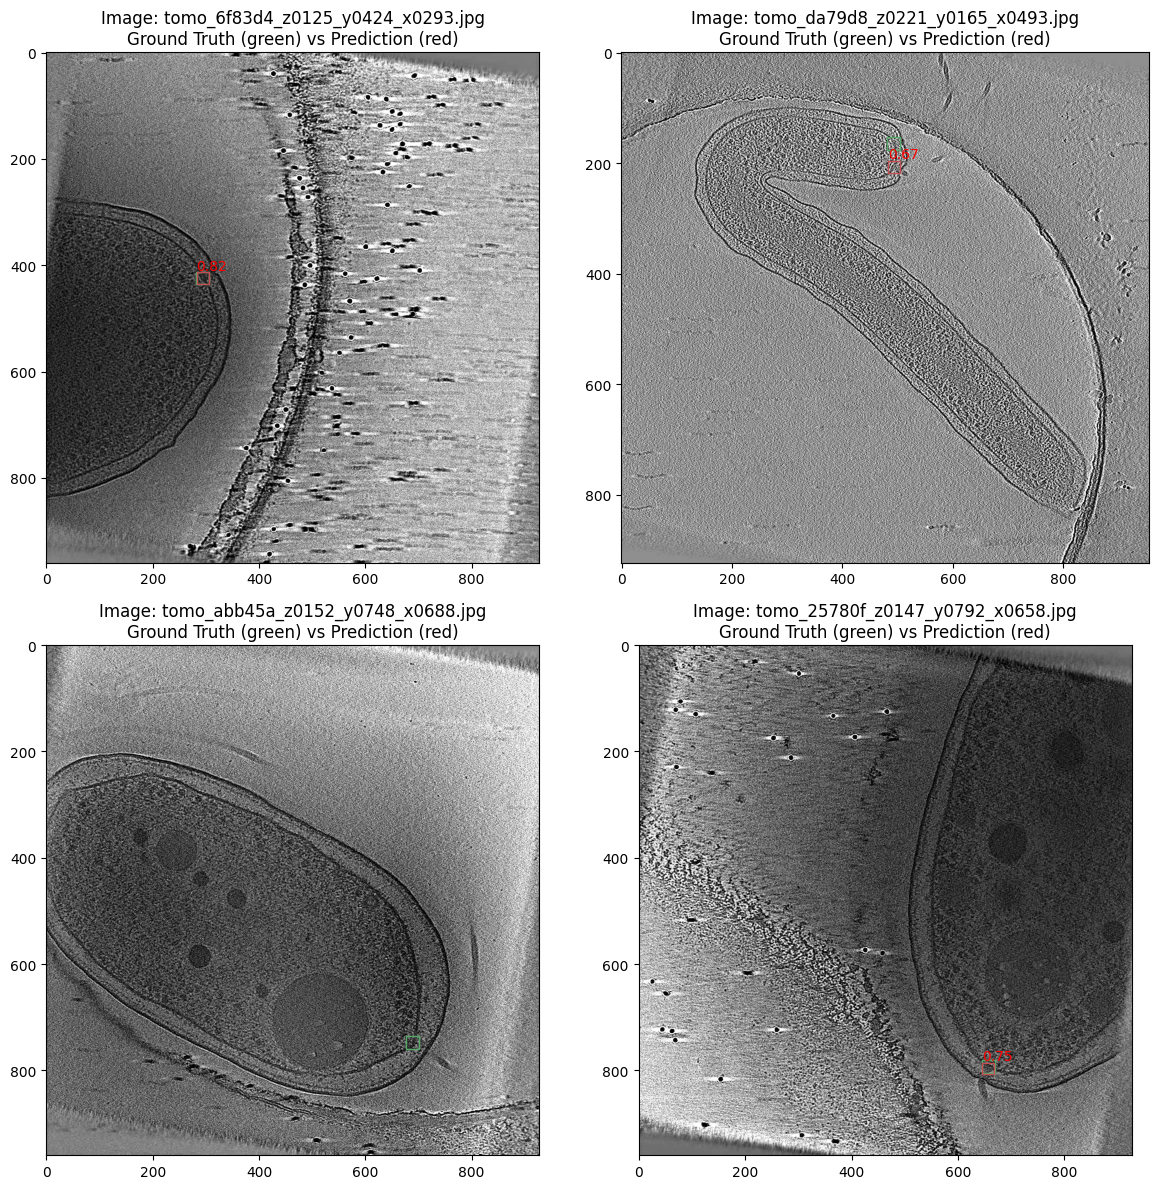

In [8]:
# Cell 7: Run the Main Pipeline
if __name__ == "__main__":
    main()
